In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd

In [3]:
df = pd.read_csv('./train_heat.csv', index_col=0)
df.columns = ['tm', 'branch_id', 'ta', 'wd', 'ws', 'rn_day', 'rn_hr1', 'hm', 'si', 'ta_chi', 'heat_demand']
df.head(5)

,tm,branch_id,ta,wd,ws,rn_day,rn_hr1,hm,si,ta_chi,heat_demand
1,2021010101,A,-10.1,78.3,0.5,0.0,0.0,68.2,-99.0,-8.2,281
2,2021010102,A,-10.2,71.9,0.6,0.0,0.0,69.9,-99.0,-8.6,262
3,2021010103,A,-10.0,360.0,0.0,0.0,0.0,69.2,-99.0,-8.8,266
4,2021010104,A,-9.3,155.9,0.5,0.0,0.0,65.0,-99.0,-8.9,285
5,2021010105,A,-9.0,74.3,1.9,0.0,0.0,63.5,-99.0,-9.2,283


In [5]:
# 선택된 열 범위에서 -98 이하인 데이터 null 변환
import numpy as np
columns_to_check = df.iloc[:, 2:]
columns_to_check = columns_to_check.apply(pd.to_numeric, errors='coerce').astype(float)
df.iloc[:, 2:] = columns_to_check

columns_to_check = columns_to_check.mask(columns_to_check <= -98, np.nan)
df.iloc[:, 2:] = columns_to_check
df.head(5)

C:\Users\jioyu\AppData\Local\Temp\ipykernel_10984\4120127351.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1         281.0
2         262.0
3         266.0
4         285.0
5         283.0
          ...  
499297     34.0
499298     35.0
499299     35.0
499300     40.0
499301     33.0
Name: heat_demand, Length: 499301, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[:, 2:] = columns_to_check


,tm,branch_id,ta,wd,ws,rn_day,rn_hr1,hm,si,ta_chi,heat_demand
1,2021010101,A,-10.1,78.3,0.5,0.0,0.0,68.2,NaN,-8.2,281.0
2,2021010102,A,-10.2,71.9,0.6,0.0,0.0,69.9,NaN,-8.6,262.0
3,2021010103,A,-10.0,360.0,0.0,0.0,0.0,69.2,NaN,-8.8,266.0
4,2021010104,A,-9.3,155.9,0.5,0.0,0.0,65.0,NaN,-8.9,285.0
5,2021010105,A,-9.0,74.3,1.9,0.0,0.0,63.5,NaN,-9.2,283.0


In [1]:
!pip install missingno

<Axes: >

Text(0, 0.5, '결측치 생성 데이터')

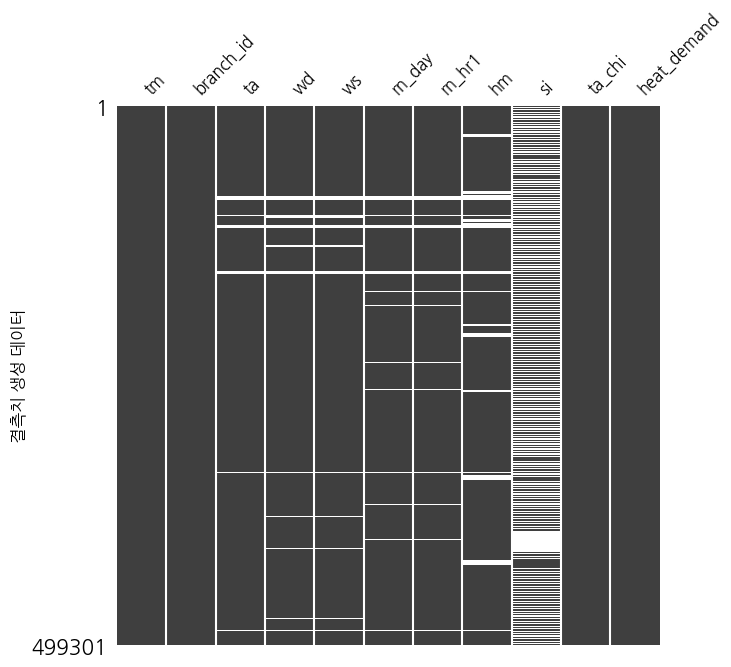

In [42]:
# plotting 환경 설정
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7,7)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.size']=12
plt.rcParams['axes.unicode_minus']=False

fig, ax = plt.subplots(1,1, figsize=(7,7))

import missingno as msno
msno.matrix(df=df, figsize=(7,7), fontsize=12, ax=ax, sparkline=False)
ax.set_ylabel('결측치 생성 데이터')

plt.show()

In [44]:
df.isnull().sum()

tm                  0
branch_id           0
ta              12997
wd              18815
ws              18815
rn_day          18626
rn_hr1          19154
hm              39717
si             232922
ta_chi             20
heat_demand        23
dtype: int64

In [7]:
df1 = df.copy()

In [9]:
# 1안. 선형보간
df_linear = df1.interpolate(method='linear').ffill().bfill()
df_linear.isna().sum()

C:\Users\jioyu\AppData\Local\Temp\ipykernel_10984\1085376562.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_linear = df1.interpolate(method='linear').ffill().bfill()


tm             0
branch_id      0
ta             0
wd             0
ws             0
rn_day         0
rn_hr1         0
hm             0
si             0
ta_chi         0
heat_demand    0
dtype: int64

In [11]:
# 2안. 하루 전의 값으로 대체
df_replace = df1
drop_columns = ['ta', 'wd','ws','rn_day','rn_hr1','hm','si']
df_replace = df_replace.drop(drop_columns, axis=1)

df_replace['datetime'] = pd.to_datetime(df_replace['tm'], format='%Y%m%d%H', errors='coerce')

def fill_missing_ta_chi_by_shift(group):
    group_indexed = group.set_index('datetime', drop=False)
    group_indexed['ta_chi'] = group_indexed['ta_chi'].fillna(group_indexed['ta_chi'].shift(freq='-1D'))
    group_indexed['heat_demand'] = group_indexed['heat_demand'].fillna(group_indexed['heat_demand'].shift(freq='-1D')).fillna(
        group_indexed['heat_demand'].shift(freq='-2D'))
    return group_indexed.reset_index(drop=True)

# 'branch_id' 별로 그룹화하여 함수 적용
df_replace = df_replace.groupby('branch_id', group_keys=False).apply(fill_missing_ta_chi_by_shift)

# 최종 결과 확인
print("\n--- 처리 후 DataFrame (결측치 대체 완료) ---")
print(df_replace.head(10))
print("\n처리 후 결측치 개수:\n", df_replace.isna().sum())


--- 처리 후 DataFrame (결측치 대체 완료) ---
           tm branch_id  ta_chi  heat_demand            datetime
0  2021010101         A    -8.2        281.0 2021-01-01 01:00:00
1  2021010102         A    -8.6        262.0 2021-01-01 02:00:00
2  2021010103         A    -8.8        266.0 2021-01-01 03:00:00
3  2021010104         A    -8.9        285.0 2021-01-01 04:00:00
4  2021010105         A    -9.2        283.0 2021-01-01 05:00:00
5  2021010106         A    -9.2        285.0 2021-01-01 06:00:00
6  2021010107         A    -8.4        285.0 2021-01-01 07:00:00
7  2021010108         A    -8.4        284.0 2021-01-01 08:00:00
8  2021010109         A    -7.5        290.0 2021-01-01 09:00:00
9  2021010110         A    -5.3        285.0 2021-01-01 10:00:00

처리 후 결측치 개수:
 tm             0
branch_id      0
ta_chi         0
heat_demand    0
datetime       0
dtype: int64


C:\Users\jioyu\AppData\Local\Temp\ipykernel_10984\2026296913.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_replace = df_replace.groupby('branch_id', group_keys=False).apply(fill_missing_ta_chi_by_shift)


In [74]:
!pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.3/150.0 MB 6.7 MB/s eta 0:00:23
    --------------------------------------- 2.9/150.0 MB 7.3 MB/s eta 0:00:21
   - -------------------------------------- 4.7/150.0 MB 8.4 MB/s eta 0:00:18
   - -------------------------------------- 6.6/150.0 MB 8.0 MB/s eta 0:00:18
   -- ------------------------------------- 8.4/150.0 MB 8.3 MB/s eta 0:00:18
   -- ------------------------------------- 10.0/150.0 MB 8.1 MB/s eta 0:00:18
   --- ------------------------------------ 11.5/150.0 MB 8.0 MB/s eta 0:00:18
   --- ------------------------------------ 13.6/150.0 MB 8.1 MB/s eta 0:00:17
   ---- ----------------------------------- 15.2/150.0 MB 8.2 MB/s eta 0:00:17
   ---- ----------------------------------- 16.8/150.0 MB 8.1 MB/s eta 0:00:17
   ----- ---------------------------------- 19.1/150.0 MB 8.3 MB/s eta 0:00:16
   ----- ---------------------------------- 21.2/150.0 MB 8.4 MB/

In [15]:
df_linear = df_linear.drop(drop_columns, axis=1)
df_linear['datetime'] = pd.to_datetime(df_linear['tm'], format='%Y%m%d%H', errors='coerce')
df_linear = df_linear.drop('tm', axis=1)
df_fill = df_replace.drop('tm', axis=1)

In [19]:
# 테스트용 XGBoost 모델 생성하여 2가지 방법 비교
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 1. 간략하게 예측에 사용할 날짜 파생변수 생성
def create_common_features(df):
    df_copy = df.copy()
    
    df_copy['year'] = df_copy['datetime'].dt.year
    df_copy['month'] = df_copy['datetime'].dt.month
    df_copy['day'] = df_copy['datetime'].dt.day
    df_copy['hour'] = df_copy['datetime'].dt.hour
    df_copy['dayofweek'] = df_copy['datetime'].dt.dayofweek
    df_copy['dayofyear'] = df_copy['datetime'].dt.dayofyear
    df_copy['weekofyear'] = df_copy['datetime'].dt.isocalendar().week.astype(int)

    # branch_id 인코딩
    le = LabelEncoder()
    df_copy['branch_id_encoded'] = le.fit_transform(df_copy['branch_id'])
    
    return df_copy

# 2. 각 DataFrame에 파생 변수 적용 ---
print("\n--- 특성 공학 적용 ---")
df_linear_features = create_common_features(df_linear)
df_fill_features = create_common_features(df_fill)

# features, target 정의
features = [
    'year', 'month', 'day', 'hour', 'dayofweek', 'dayofyear', 'weekofyear',
    'branch_id_encoded'
]
target = 'heat_demand'

# 3. 모델 학습 및 평가
def train_and_evaluate_xgboost(df, model_name):
    print(f"\n--- {model_name} 모델 학습 및 평가 시작 ---")
    
    # 시간 순서대로 학습/테스트 데이터 분할
    split_point = int(len(df) * 0.8)
    train_df = df.iloc[:split_point]
    test_df = df.iloc[split_point:]

    X_train = train_df[features]
    y_train = train_df[target]
    X_test = test_df[features]
    y_test = test_df[target]
    
    print(f"{model_name} 학습 데이터 shape: {X_train.shape}")
    print(f"{model_name} 테스트 데이터 shape: {X_test.shape}")

    # XGBoost Regressor 모델 생성
    model = xgb.XGBRegressor(
        objective='reg:squarederror', # 회귀 문제
        n_estimators=300,             # 트리의 개수
        learning_rate=0.05,          
        max_depth=5,                  
        random_state=42,
        n_jobs=-1,                    # 모든 CPU 코어 사용
        eval_metric='rmse'            
    )
    
    # model.fit() 호출 시 callbacks 인자 사용
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

    # 예측
    y_pred = model.predict(X_test)

    # 성능 평가
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} - RMSE: {rmse:.4f}")
    print(f"{model_name} - MAE: {mae:.4f}")
    print(f"{model_name} - R2-score: {r2:.4f}")
    
    return rmse, mae, r2

# 4. 각 DataFrame으로 모델 학습 및 평가 수행
rmse_linear, mae_linear, r2_linear = train_and_evaluate_xgboost(df_linear_features, "선형 보간 (df_linear)")
rmse_fill, mae_fill, r2_fill = train_and_evaluate_xgboost(df_fill_features, "대체 보간 (df_fill)")

# 5. 결과 비교
print("\n" + "="*40)
print("--- XGBoost 모델 성능 비교 ---")
print("="*40)
print(f"{'Metric':<10} {'Linear Interpolation':<25} {'Fill Interpolation':<25}")
print(f"{'-'*10} {'-'*25} {'-'*25}")
print(f"{'RMSE':<10} {rmse_linear:<25.4f} {rmse_fill:<25.4f}")
print(f"{'MAE':<10} {mae_linear:<25.4f} {mae_fill:<25.4f}")
print(f"{'R2-score':<10} {r2_linear:<25.4f} {r2_fill:<25.4f}")
print("="*40)

if rmse_linear < rmse_fill:
    print("선형 보간 데이터가 대체 보간 데이터보다 RMSE가 더 낮아 성능이 좋습니다.")
elif rmse_linear > rmse_fill:
    print("대체 보간 데이터가 선형 보간 데이터보다 RMSE가 더 낮아 성능이 좋습니다.")
else:
    print("두 보간 방식의 RMSE 성능이 유사합니다.")

print("\n**참고:** RMSE는 낮을수록 좋고, R2-score는 1에 가까울수록 좋습니다.")


--- 특성 공학 적용 ---

--- 선형 보간 (df_linear) 모델 학습 및 평가 시작 ---
선형 보간 (df_linear) 학습 데이터 shape: (399440, 8)
선형 보간 (df_linear) 테스트 데이터 shape: (99861, 8)
선형 보간 (df_linear) - RMSE: 73.6232
선형 보간 (df_linear) - MAE: 56.1870
선형 보간 (df_linear) - R2-score: -1.0461

--- 대체 보간 (df_fill) 모델 학습 및 평가 시작 ---
대체 보간 (df_fill) 학습 데이터 shape: (399440, 8)
대체 보간 (df_fill) 테스트 데이터 shape: (99861, 8)
대체 보간 (df_fill) - RMSE: 73.8397
대체 보간 (df_fill) - MAE: 56.2881
대체 보간 (df_fill) - R2-score: -1.0582

--- XGBoost 모델 성능 비교 ---
Metric     Linear Interpolation      Fill Interpolation       
---------- ------------------------- -------------------------
RMSE       73.6232                   73.8397                  
MAE        56.1870                   56.2881                  
R2-score   -1.0461                   -1.0582                  
선형 보간 데이터가 대체 보간 데이터보다 RMSE가 더 낮아 성능이 좋습니다.

**참고:** RMSE는 낮을수록 좋고, R2-score는 1에 가까울수록 좋습니다.
